In [1]:
import numpy as np
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [41]:
node_pos_init = np.loadtxt('pos_init.csv', delimiter=',')
node_pos_before = np.loadtxt('pos_before.csv', delimiter=',')
node_pos_after = np.loadtxt('pos_after_200.csv', delimiter=',')

before_movement = node_pos_before - node_pos_init
after_movement = node_pos_after - node_pos_init

cos_error = []
nmse = []
error = []
rel_error = []

for i in range(len(before_movement)):
    if np.linalg.norm(before_movement[i]) < 1e-4 or np.linalg.norm(after_movement[i]) < 1e-4:
        nmse.append(0.)
        error.append(0.)
        rel_error.append(0.)
        continue
    # cos_error.append(np.dot(before_movement[i], after_movement[i]) / (np.linalg.norm(before_movement[i]) * np.linalg.norm(after_movement[i])))
    nmse.append(np.sqrt(np.sum((before_movement[i] - after_movement[i])**2) / np.sum(before_movement[i]**2 + after_movement[i]**2)))
    error.append(np.linalg.norm(before_movement[i] - after_movement[i]))
    rel_error.append(np.linalg.norm(before_movement[i] - after_movement[i]) / np.linalg.norm(before_movement[i]))
    # rel_error.append(np.linalg.norm(before_movement[i] - after_movement[i]) / np.linalg.norm(before_movement[i]))

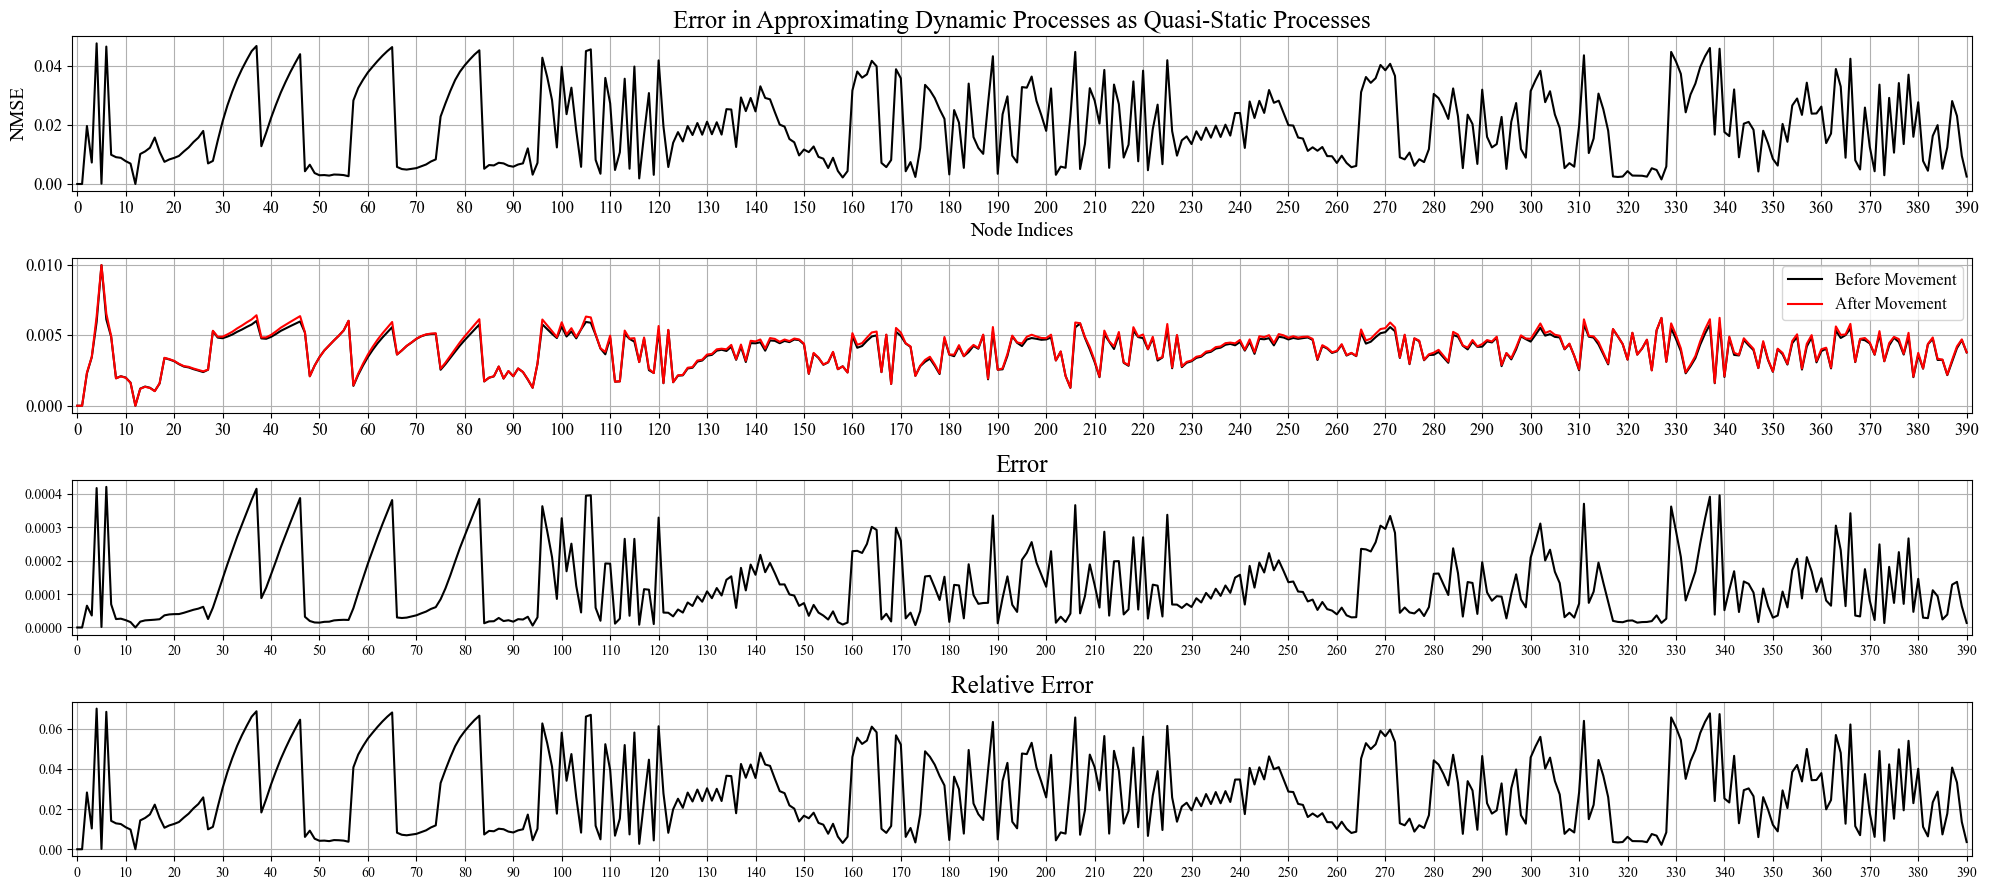

In [42]:
fig, axs = plt.subplots(4, 1, figsize=(20, 9))

axs_nmse = axs[0]
axs_nmse.plot(nmse, c='k', lw=1.5, label='NMSE')
axs_nmse.set_xlim([-1, len(nmse)])
axs_nmse.set_title('Error in Approximating Dynamic Processes as Quasi-Static Processes', fontsize=18, fontname='Times New Roman')
axs_nmse.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
axs_nmse.set_ylabel('NMSE', fontsize=14, fontname='Times New Roman')
axs_nmse.xaxis.set_major_locator(MultipleLocator(10))
axs_nmse.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
axs_nmse.get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴中科学计数法中的指数大小
axs_nmse.grid('True')

axs_movement = axs[1]
axs_movement.plot(np.linalg.norm(before_movement, axis=1), c='k', lw=1.5, label='Before Movement')
axs_movement.plot(np.linalg.norm(after_movement, axis=1), c='r', lw=1.5, label='After Movement')
axs_movement.set_xlim([-1, len(error)])
axs_movement.xaxis.set_major_locator(MultipleLocator(10))
axs_movement.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
axs_movement.get_yaxis().get_offset_text().set_fontsize(12)    # 设置坐标轴中科学计数法中的指数大小
axs_movement.grid('True')
axs_movement.legend(fontsize=12)

axs_error = axs[2]
axs_error.plot(error, c='k', lw=1.5, label='Error')
axs_error.set_title('Error', fontsize=18)
axs_error.set_xlim([-1, len(error)])
axs_error.xaxis.set_major_locator(MultipleLocator(10))
axs_error.grid('True')

axs_rel_error = axs[3]
axs_rel_error.plot(rel_error, c='k', lw=1.5, label='Relative Error')
axs_rel_error.set_title('Relative Error', fontsize=18)
axs_rel_error.set_xlim([-1, len(rel_error)])
axs_rel_error.xaxis.set_major_locator(MultipleLocator(10))
axs_rel_error.grid('True')

plt.tight_layout()
plt.show()

In [43]:
smaple_pos_np = np.loadtxt('sample_pos.csv', delimiter=',')
sample_pos_x = smaple_pos_np[:, 0]
sample_pos_y = smaple_pos_np[:, 1]
sample_pos_z = smaple_pos_np[:, 2]

# print(f'斜率: {(sample_pos_x[500]-sample_pos_x[1000])/500}')

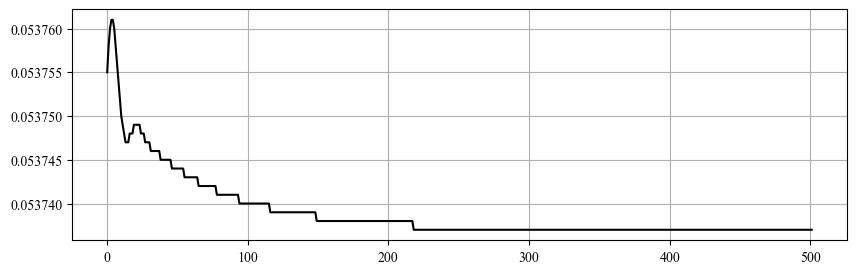

In [44]:
fig, axs = plt.subplots(1, 1, figsize=(10, 3))
axs.plot(sample_pos_x[499:], c='k', lw=1.5)
axs.grid('True')

plt.show()